In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("data//Football_Player_Stats.csv")

In [6]:
df.head()
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Name              18979 non-null  str  
 1   Attacking         18979 non-null  int64
 2   Crossing          18979 non-null  int64
 3   Finishing         18979 non-null  int64
 4   Heading Accuracy  18979 non-null  int64
 5   Short Passing     18979 non-null  int64
 6   Volleys           18979 non-null  int64
 7   Skill             18979 non-null  int64
 8   Dribbling         18979 non-null  int64
 9   Curve             18979 non-null  int64
 10  FK Accuracy       18979 non-null  int64
 11  Long Passing      18979 non-null  int64
 12  Ball Control      18979 non-null  int64
dtypes: int64(12), str(1)
memory usage: 1.9 MB


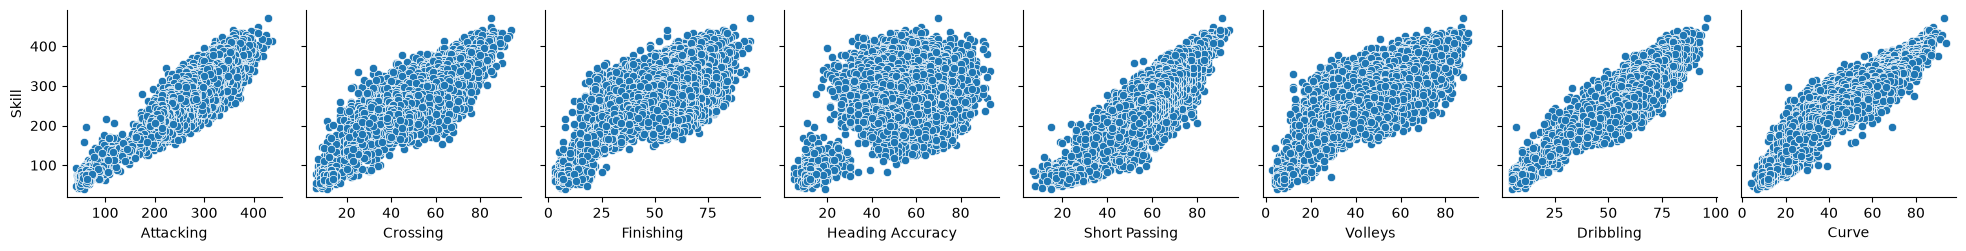

In [11]:
sns.pairplot(df, x_vars=['Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Dribbling', 'Curve'], y_vars=['Skill'])

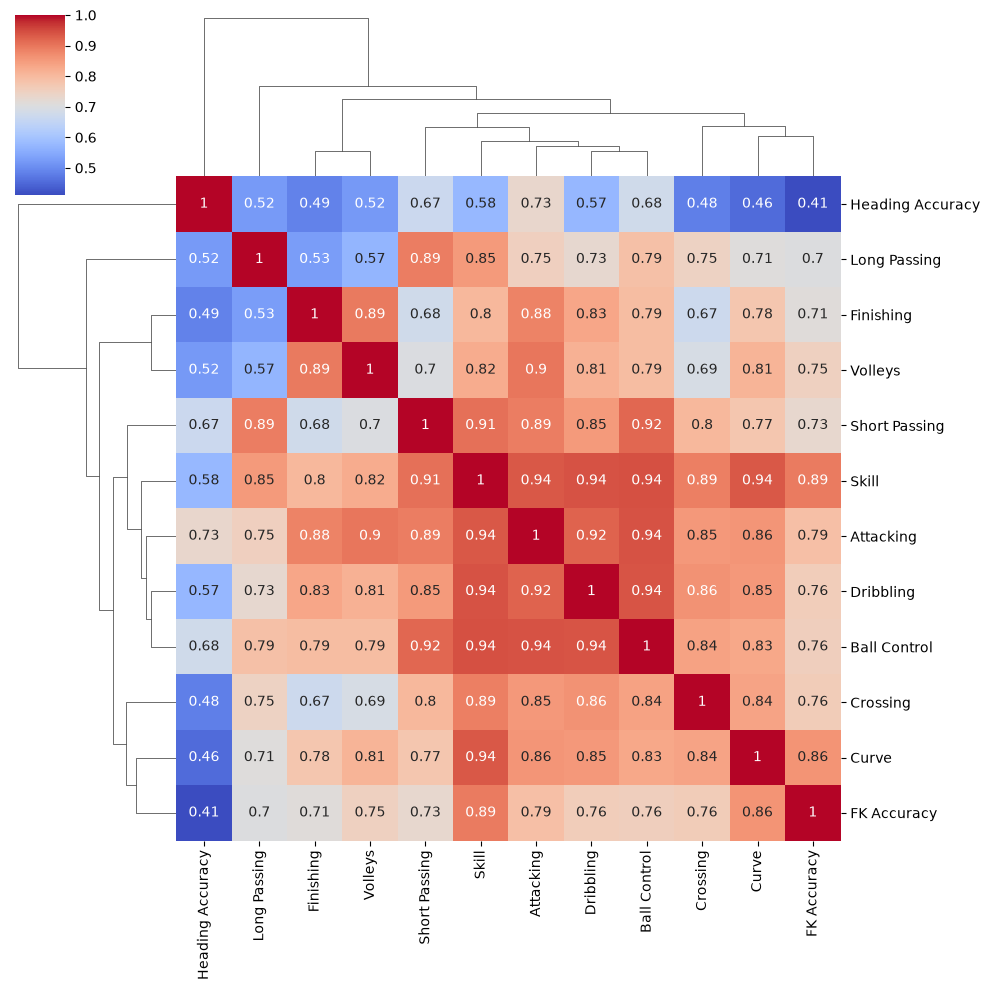

In [19]:
sns.clustermap(
    df.loc[:, 'Attacking':'Ball Control'].corr(),
    annot=True,
    cmap="coolwarm"
)

In [20]:
X = df.drop(columns=['Name', 'Skill'])
y = df['Skill']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[0.,0.,0.,...,1.,1.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['Attacking','Crossing','Finishing',...,'FK Accuracy','Long Passing', 'Ball Control']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.785e-12
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [24]:
model.coef_, model.intercept_

(array([ 7.21186217e-15,  1.33226763e-15,  2.33146835e-15,  2.83106871e-15,
         1.83186799e-15, -1.11022302e-16,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00]),
 np.float64(-2.7853275241795927e-12))

In [25]:
y_pred = model.predict(X_test)

In [26]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

rmse, mae, mape, r2

(np.float64(8.187047444818692e-13),
 5.948612870289321e-13,
 4.053488782944642e-15,
 1.0)

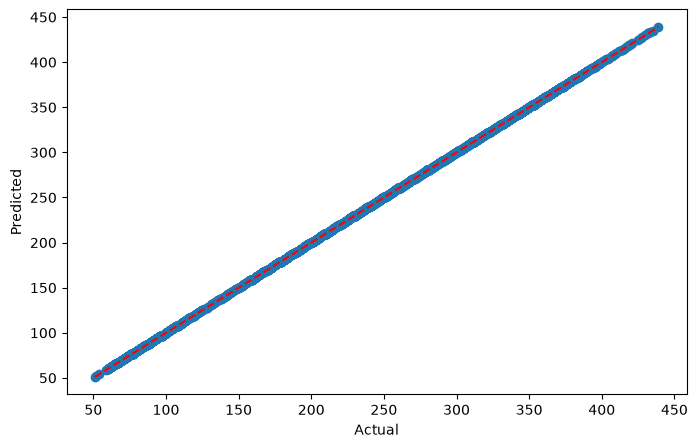

In [31]:
fig, ax = plt.subplots(figsize = (8,5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
